This is the main file for Dennis Mitzeus' bachelor thesis project. The project includes data preprocessing, project structuring, technical implementation, and evaluation.

The current Architecture looks like this:

<img width="400px" src="./figures/artifact_flowchart_new.png"></img>

## Structure

This project will go through

1. Data Preprocessing
2. API setup
3. Technical Implementation
4. Evaluation

## Project

In [1]:
# Setting up warning and logging filters, and mutliprocessing before anything else.
import os
import warnings
os.environ["VLLM_LOGGING_LEVEL"] = "ERROR"  # only show actual errors
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import logging
logging.getLogger("vllm").setLevel(logging.ERROR)
logging.getLogger("vllm.engine").setLevel(logging.ERROR)

import torch.multiprocessing as mp
from vllm import LLM, SamplingParams

mp.set_start_method("spawn", force=True)

In [2]:
# Fixes need to restart kernel everytime I update components in separate files
%load_ext autoreload
%autoreload 2

%matplotlib inline

# Import Declarations
from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import re
import contractions
import requests
import tarfile
import shutil
import csv
from dotenv import load_dotenv, dotenv_values
import os
import json
import spacy
import sqlite3
import time

In [3]:
TOTAL_SIZE = 2000 # Total size of each flashcard set
BATCH_SIZE = 20 # How many words get introduced at a time eg. 20: ask LLM with 20 flashcards, then again with 40, then 60,..., until total size reached
MODEL_SAMPLE_SIZE = 10 # How many times to ask the same question (to get a distribution of probabilistic results)

### Data Preprocessing

#### Status for language Datasets Found:
* ✅ Swedish: Kelly (https://spraakbanken.gu.se/resurser/kelly)
* ✅ Spanish: ChatSubs (https://linkinghub.elsevier.com/retrieve/pii/S2352340923006650) (Data link: https://github.com/conversa-ai/ChatSubs)
* ✅ Korean: 한국어 학습용 어휘 목록(엑셀 파일) (TOPIK, from National Institute of Korean Language) (https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)

#### Dataset explanations

##### Swedish

The Swedish dataset "Kelly" is used for Swedish. Swedish dataset contains 9 columns: "ID", "Raw freq", "WPM" "CEFR levels", "Source", "Grammar", "Swedish items for translation", "Word classes", and "Examples". 

Raw freq corresponds to the total frequency over the whole extracted corpus, WPM corresponds to a ratio of how many words per 1 000 000 words is this word, CEFR levels correspond to how advanced a word is following the Common European Framework of Reference for Languages, Source is from which corpus the word comes from, Grammar corresponds to certain prefixes or suffixes some word classes inherit (for example "att" before all root verbs), Swedish items for translation is the word itself, word classes correspond to which grammatical type a word is (more details under "Lookup" workspace in file datasets/1-raw/swedish.xls), lastly, examples provide example sentences of use for some words.

##### Spanish

The Spanish dataset "ChatSubs" is a collection of almost 20 000 000 dialogue subtitles from various kinds of movies and series. As this is not a preprocessed list of the most common words, it needs preprocessing.

By structuring all dialogues to be inputted directly into an NLP preprocessing library such as spaCy, a full database of lemmas, their PoS (grammar type) and frequency can be constructed. The frequency and PoS can then be used to determine which words in each grammar type qualify for the final flashcard set.

##### Korean

Korean dataset is from the National Korean Language Institute which is a put together list of the most common words in the Korean language for foreign learners practicing for the TOPIK (Test of Proficiency in Korean) test. Korean dataset contains 5 columns: "순위", "단어", "품사", "풀이", and "등급".

순위 corresponds to the frequency ranking based on a 2002 researcher report named "Survey on Modern Korean Usage Frequency", 단어 corresponds to the word itself, 품사 refers to the grammatical type a word is (more details can be found at [the official dataset site](https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)),풀이 refers to the Hanja (漢字) versions of some words, and 등급 refers to which TOPIK level a word is in where A means basic B is intermediate and C is advanced level.

### Preprocessing based on some criteria

For our preprocessing we need to fulfill some critera to get a good subset of the datasets viable for testing in the thesis architecture. 

It requires:

1. Vocabulary list of 100 Words per Language
2. A varied set of grammar types (Nouns, Verbs etc.), some weight more than others such as verbs being more important than conjunctions for basic language.
3. The words should be the most common in most cases. This means relative frequency is better than raw frequency.

#### Batches

Batches are subsets of a final dataset for gradual introduction into the thesis architecture system and works similar to smaller independent datasets inside the bigger one, meaning each batch will have similar word type ratios and not purely based on commonality (in case of a vocabulary list of 100 words, most adjectives may be top 60 meaning no adjectives can ever be used until batches after top 60 gets introduced)

This is a visual image of batches: 

<img src="./figures/flashcard_batches.png" width="400px"></img>

### Preprocessing

In [4]:
from src.preprocessing.language.general import create_sorted_flashcard_set

In [5]:
# This is the final structure of each preprocessed final list
final_example_df = pd.DataFrame(
 columns=["word", "pos", "frequency"]
)

for i in range(TOTAL_SIZE):
    final_example_df = pd.concat([final_example_df, pd.DataFrame([{"word": "example word", "pos": "verb", "frequency": 1}])], ignore_index=True)

final_example_df

,word,pos,frequency
0,example word,verb,1
1,example word,verb,1
2,example word,verb,1
3,example word,verb,1
4,example word,verb,1
...,...,...,...
1995,example word,verb,1
1996,example word,verb,1
1997,example word,verb,1
1998,example word,verb,1


#### Swedish

In [6]:
from src.preprocessing.language.swedish import remove_and_merge_pos as swedish_remove_and_merge_pos

In [7]:
swedish_raw = pd.read_csv("data/2-extracted/swedish.csv", sep=";")  # import
swedish_raw.isnull().sum()

ID                                  0
Raw freq                         2650
WPM                                 0
CEFR levels                         0
Source                              0
Grammar                          2841
Swedish items for translation       0
Word classes                        0
Examples                         8180
dtype: int64

In [8]:
# changing WPM to numeric
swedish_raw["WPM"] = swedish_raw["WPM"].str.replace(",", ".").astype("Float64")

# drop rows with super high WPM values (outliers)
swedish_raw = swedish_raw[swedish_raw["WPM"] < 1000000]

In [9]:
swedish_clump_word_classes = {
    "noun": ["noun", "noun-en", "noun-ett", "noun-en/-ett"],
    "verb": ["verb", "aux verb"],
}

swedish_processed = swedish_remove_and_merge_pos(data=swedish_raw, clump_word_classes=swedish_clump_word_classes)

,word,pos,frequency
86,och,conj,26019.68
87,vara,verb,23017.26
88,i,prep,19272.89
89,ha,verb,15983.31
90,dess,pronoun,15935.58
...,...,...,...
5598,nedanför,prep,7.11
5681,i ljuset av,prep,6.94
6118,väster om,prep,6.19
6371,envar,pronoun,5.44


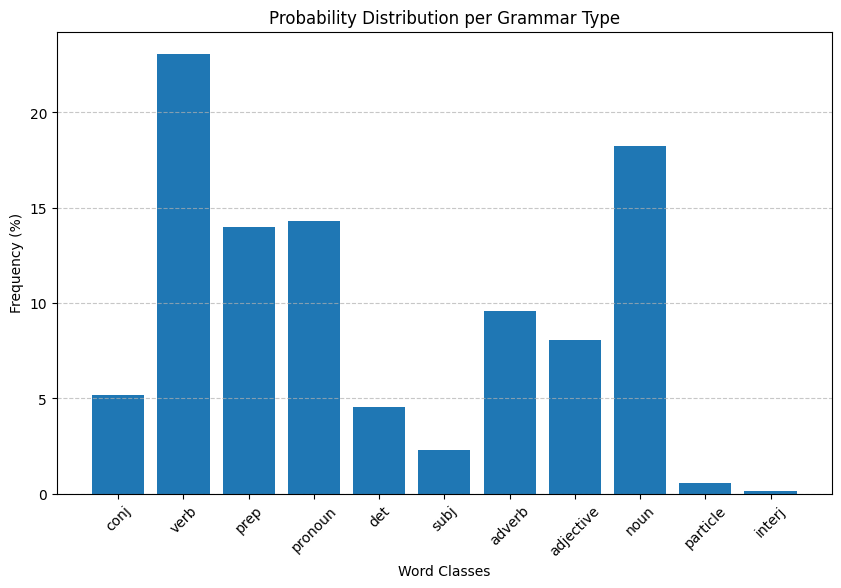

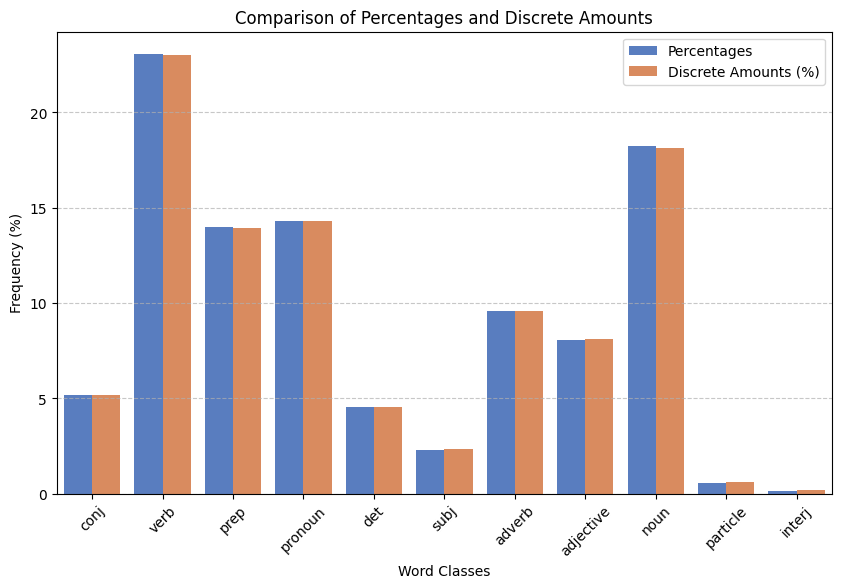

In [11]:
swedish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=swedish_processed,
    data_columns=["Swedish items for translation", "Word classes", "WPM"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="swedish",
    target_columns=["word", "pos", "frequency"],
    drop_pos=["numeral", "proper name", "particip"],
    limit=TOTAL_SIZE,
)

display(swedish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Spanish

In [ ]:
from src.preprocessing.language.spanish import load_dataset as load_spanish_dataset
from src.preprocessing.language.spanish import (
    extract_data_from_dataset as spanish_extract_data_from_dataset,
)
from src.preprocessing.language.spanish import (
    grammar_preprocessing as spanish_grammar_preprocessing,
)
from src.preprocessing.language.spanish import (
    finalize_dataset as spanish_finalize_dataset,
)
from src.preprocessing.language.spanish import remove_artifact_entries as spanish_remove_artifact_entries

In [ ]:
load_spanish_dataset() # downloads Spanish Dataset (ChatSubs) to /data/1-raw/spanish/

In [ ]:
spanish_extract_data_from_dataset(limit=20000, limit_sampling_seed=42) # extracts all dialogues from all documents into one .csv document
# spanish_extract_data_from_dataset(limit=1) # extracts all dialogues from all documents into one .csv document

In [ ]:
spanish_df = spanish_grammar_preprocessing(
    nlp_size="small",
    cores_to_use=6,
    import_chunk_size=120000,
    processing_chunk_size=4000,
)  # Does preprocessing: tokenization, lemmatization, PoS tagging

print(spanish_df.sort_values(by="frequency", ascending=False).head(10))

In [ ]:
spanish_raw = spanish_finalize_dataset(limit=5000) # writes and gives top N entries
# spanish_raw = spanish_finalize_dataset(limit=TOTAL_SIZE) # writes and gives top N entries

spanish_raw

In [ ]:
spanish_processed = spanish_remove_artifact_entries(spanish_raw, word_column="lemma")

In [ ]:
spanish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=spanish_processed, 
    data_columns=["lemma", "pos", "WPM"], 
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="spanish",
    target_columns=["word", "pos", "frequency"], 
    drop_pos=["PROPN", "NUM", "PUNCT"],
    limit=TOTAL_SIZE)

display(spanish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Korean

In [ ]:
korean_raw = pd.read_csv("data/2-extracted/korean.csv", sep=";")  # import
korean_raw.isnull().sum()

In [ ]:
korean_raw

In [ ]:
korean_raw = korean_raw.dropna(subset=["순위"]) # drops words where there is no ranking

In [ ]:
korean_raw["품사"].unique()

In [ ]:
# remove 단어 numbers
korean_raw["단어"] = korean_raw["단어"].str.replace(
    r"\d+$", "", regex=True
)

In [ ]:
# replace korean names for display purposes
korean_raw["품사"] = korean_raw["품사"].replace(
    {
        "명": "noun",
        "동": "verb",
        "부": "adv",
        "형": "adj",
        "보": "aux",
        "의": "dep",
        "관": "det",
        "불": "neg",
        "대": "pron",
        "수": "num",
        "감": "intj",
    }
)

In [ ]:
# As TOPIK dont have any frequency ranking, I'll weight the ranking instead
korean_raw["frequency_est"] = 1 / korean_raw["순위"]

In [ ]:
korean_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=korean_raw,
    data_columns=["단어", "품사", "frequency_est"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="korean",
    target_columns=["word", "pos", "frequency"],
    drop_pos=[],
    limit=TOTAL_SIZE,
)

display(korean_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

### Technical Implementation OLD ChatGPT Version

In [ ]:
# imports
# from openai import OpenAI
import openai as client

from ai.OLD_models import Conversation_Model, Conversation
from src.ai.prompts import REVISED_PROMPT_STRING as SYSTEM_PROMPT_STRING

In [ ]:
load_dotenv()
# client = OpenAI(api_key=os.getenv("OPENAI_KEY"))
client.api_key = os.getenv("OPENAI_KEY")

In [ ]:
swedish_vocab = pd.read_csv("data/3-final/swedish100.csv").sort_values(by="frequency", ascending=False)
spanish_vocab = pd.read_csv("data/3-final/spanish100.csv").sort_values(
    by="frequency", ascending=False
)
korean_vocab = pd.read_csv("data/3-final/korean100.csv").sort_values(
    by="frequency", ascending=False
)

In [ ]:
test_questions_swedish = [  # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    # "When do you use 'är' vs 'har' in swedish?",
    # "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    # "What does 'lagom' mean in swedish?",
    # "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

test_questions_spanish = []
test_questions_korean = []

In [ ]:
print(
    f"""
Current Setup:
    Total Nr. Questions Swedish: {len(test_questions_swedish)}
    Total Nr. Questions Spanish: {len(test_questions_spanish)}
    Total Nr. Questions Korean: {len(test_questions_korean)}

    Flashcard Set Size:  {TOTAL_SIZE}
    Batch Size:          {BATCH_SIZE}
    Total Nr. Batches:   {TOTAL_SIZE // BATCH_SIZE}

    Total Nr. Samples (of generator model):   {MODEL_SAMPLE_SIZE}
"""
)

In [ ]:
# TEST

conversation = Conversation_Model(
    SYSTEM_PROMPT_STRING,
    model_client=client,
    model_name="gpt-5.1",
    keep_history=True,
    save_history_to_file=False,
    max_output_tokens=10,
    tokenwise_generation=True,
)

conv = ""
last_complete_token = None
token_part = ""

conversation.import_word_library(swedish_vocab)

In [ ]:
fully_finished = False
while fully_finished == False:
    new_prompt = False if len(conv) > 0 else True


    response, response_top_logprobs, generated_response, is_finished = (
        conversation.generate_tokenwise(
            'What is the difference between "en" and "ett" in swedish? Explain in only one short sentence.',
            conv,
            n_tokens=1,
            top_logprobs=20,
            new_prompt=new_prompt
        )
    )

    conv += generated_response

    fully_finished = is_finished

    if generated_response[0] == " ":
        # hit a new sequence
        last_complete_token = token_part
        token_part = generated_response.replace(" ", "")
    else:
        token_part += generated_response

    print(f"Last completed token: {last_complete_token}")
    print(f"Part token: {token_part}")
    print(f"Is finished: {is_finished}")


In [ ]:
for part in conversation.history:
    print(f"{part["role"]}: {part["content"] if part["role"] == "assistant" else ""}")

In [ ]:
generated_response

In [ ]:
conv

In [ ]:
conversation = ""
conversations_data = []

total_runs = (
    (TOTAL_SIZE // BATCH_SIZE) * len(test_questions_swedish) * MODEL_SAMPLE_SIZE
)

print(f"A total of {total_runs} conversations will be generated.")

run_counter = 0
for question_i, question in enumerate(test_questions_swedish):
    for batch_i in range(1):
    # for batch_i in range(TOTAL_SIZE // BATCH_SIZE):
        for sample_i in range(MODEL_SAMPLE_SIZE):
            run_counter += 1

            vocab_subset = swedish_vocab[: (batch_i + 1) * BATCH_SIZE]

            conversation = Conversation_Model(
                SYSTEM_PROMPT_STRING,
                model_client=client,
                model_name="gpt-5.2",
                keep_history=True,
                save_history_to_file=False,
                max_output_tokens=10,
                tokenwise_generation=True,
            )

            # add flashcard limits
            conversation.import_word_library(vocab_subset)

            prompt = question
            response_obj, response = conversation.ask(prompt)
            print(
                f"{run_counter}/{total_runs}: Sample {sample_i + 1} of question nr {question_i + 1} using {(batch_i + 1) * BATCH_SIZE} words Generated."
            )
            # print(f"You: {question}")
            # print(f"Model: {response}")
            # print("\n")

            conversations_data.append(
                Conversation(
                    id=f"{batch_i + 1}"
                    + f"{(batch_i + 1) * BATCH_SIZE}"
                    + f"{sample_i + 1}",
                    question_id=question_i,
                    sample_id=sample_i,
                    nr_vocab=(batch_i + 1) * BATCH_SIZE,
                    question=question,
                    response=response,
                    word_limits=conversation.flashcards,
                )
            )

            # as JSON
            with open(
                f"chats/test_questionings/question_{question_i + 1}_batchsize_{(batch_i + 1) * BATCH_SIZE}_sample_{sample_i + 1}.json",
                "w",
            ) as f:
                json_history = json.dumps(conversation.history, indent=4)
                f.write(json_history)

print("Done!")

### Technical Implementation

Technical implementation involves prompting, model design, flashcard imports, batch managements and running to gather data about the performance of measurable components of the system.

In this case testing to ask about different components of the swedish language and see how it performs.

In [45]:
swedish_vocab = pd.read_csv("data/3-final/swedish2000.csv").sort_values(
    by="frequency", ascending=False
)
spanish_vocab = pd.read_csv("data/3-final/spanish100.csv").sort_values(
    by="frequency", ascending=False
)
korean_vocab = pd.read_csv("data/3-final/korean100.csv").sort_values(
    by="frequency", ascending=False
)

In [35]:
test_questions_swedish = [  # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    "When do you use 'är' vs 'har' in swedish?",
    "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    "What does 'lagom' mean in swedish?",
    "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

test_questions_spanish = [
    "What is the difference between 'el' and 'la' in spanish?"
    "What is the difference between 'está' and 'estaba' in spanish?"
    "" # TODO
]
test_questions_korean = [] # TODO

In [36]:
print(
    f"""
Current Setup:
    Total Nr. Questions Swedish: {len(test_questions_swedish)}
    Total Nr. Questions Spanish: {len(test_questions_spanish)}
    Total Nr. Questions Korean: {len(test_questions_korean)}

    Flashcard Set Size:  {TOTAL_SIZE}
    Batch Size:          {BATCH_SIZE}
    Total Nr. Batches:   {TOTAL_SIZE // BATCH_SIZE}

    Total Nr. Samples (of generator model):   {MODEL_SAMPLE_SIZE}
"""
)


Current Setup:
    Total Nr. Questions Swedish: 5
    Total Nr. Questions Spanish: 1
    Total Nr. Questions Korean: 0

    Flashcard Set Size:  2000
    Batch Size:          20
    Total Nr. Batches:   100

    Total Nr. Samples (of generator model):   10



I would think the easiest way is to do one call to analyze the target and preferred language of the user before answering, then i prompt the vLLM to answer in the preferred language, if preferred language and target is the same, then apply a penalty to words outside of the vocabulary list, then when extract top logprobs and base the token off of some custom logic. This is my proposal. As for beam search, it would be at word level, as you proposed in strategy B.

so you propose I could instaed of using logit_bias I do the inverse and apply that penalty on the top logprobs N+extra padding first and then pick the top N

For stopping the search:
I will explain now what I think you mean and you correct me if any intuition is incorrect. So I understood it as when a beam reaches an EOS tag, I have it and calculate a normalized probability off of it, then you close that beam and continue on the ones yet not completed, but now you calculate normalized probability for each beam in each step, if the probability already is worse than the completed sequence, prune it as it can never win and continue on the ones that still has a better probability, and replace the finished one with the next finished one if that one has the better normalized probability until all beams are worse than the frozen one, then that one had the highest normalized probability. Is this correct?

In [4]:
from src.ai.vLLM import vLLM_run, initialize_vLLM
from src.ai.tools import get_max_token_length_of_vocab
from src.ai.models import build_chat_with_token_ids, generate_token, find_optimal_beams
from vllm.transformers_utils.tokenizer import get_tokenizer
from vllm.inputs import TokensPrompt

from src.ai.beam_search import BeamSearch

In [38]:
# HYPERPARAMETERS
# --------------------------------------------/>

# Models
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct-AWQ"     # Light model with AWQ quantization
# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct-AWQ"   # Heavier model with AWQ quantization

# vLLM Initialization
DTYPE = "half"                                  # dtype
GPU_MEMORY_UTILIZATION = 0.6                    # GPU Memory Utilization
MAX_MODEL_LEN = 30000                           # Maximum allowed tokens to be generated by the vLLM model. 
ENABLE_PREFIX_CACHING = True                    # IMPORTANT: "caches the KV cache of existing queries, so that a new query can directly reuse the KV cache if it shares the same prefix with one of the existing queries, allowing the new query to skip the computation of the shared part." -- vLLM Documentation (https://docs.vllm.ai/en/latest/features/automatic_prefix_caching/)

# Sampling Parameters
TEMPERATURE = 0.5                               # Temperature
# TOP_K = 0.9                                   # Top K
MAX_TOKENS = 1                                  # Max generated tokens at a time. Keep at 1 for beam search logic
BEAM_SIZE = 2                                   # Beam Size
BEAM_CONSTRAINT_PADDING = 20                    # Extra padding to have backup logprobs in case too many gets pruned from vocabulary or probability constraints
LOGPROBS = BEAM_SIZE + BEAM_CONSTRAINT_PADDING  # Number of logprobs to extract from vLLM
REPETITION_PENALTY = 2                          # vLLM repetition penalty, default 1 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
PRESENCE_PENALTY = 0.0                          # vLLM presence penalty, default 0 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
FREQUENCY_PENALTY = 0.2                         # vLLM frequency penalty, default 0 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
LOGITS_PREPROCESSORS = []                       # vLLM Logits Preprocessors
LOGPROB_NORM_ALPHA = 0.2                        # Weight variable for Normalized Logprobs, 1 = fully equal, makes longer sequences always better, 0 = no effect, default = 0.6

# Sequence Generation
MAX_RESPONSE_TOKEN_LENGTH = 300                 # Nr allowed token length for the final sequence length
USE_WORD_CONSTRAINT = True                      # Applies penalty term on words' logprob which are not in allowed vocabulary
WORD_CONSTRAINT_TYPE = "soft"                   # "soft" | "hard", applies 
WORD_SOFT_CONSTRAINT_PENALTY = 1                # Soft penalty to discourage use of non-allowed words while allowing some slack. Increase if using too many non-allowed words

# Misc
VERBOSE = "sequence"                            # "full" | "sequence" | None Prints progress from inference

# --------------------------------------------/>

In [9]:
llm = initialize_vLLM(
    model=MODEL_NAME,
    dtype=DTYPE,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    max_model_len=MAX_MODEL_LEN,
    enable_prefix_caching=ENABLE_PREFIX_CACHING,  # IMPORTANT: Enables KV Cahce reuse between queries with shared prefixes
    max_logprobs=LOGPROBS + 20, # overhead to switch up and down
    trust_remote_code=True,
)

tokenizer = get_tokenizer(MODEL_NAME)

[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.52it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.52it/s]
(EngineCore pid=862199) 
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 17.29it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 23.78it/s]


In [46]:
# vocab = swedish_vocab["word"].tolist()
swedish_word_list = swedish_vocab["word"].tolist()
spanish_word_list = spanish_vocab["word"].tolist()
korean_word_list = korean_vocab["word"].tolist()

swedish_max_possible_token_length = get_max_token_length_of_vocab(swedish_word_list, tokenizer=tokenizer)
spanish_max_possible_token_length = get_max_token_length_of_vocab(spanish_word_list, tokenizer=tokenizer)
korean_max_possible_token_length = get_max_token_length_of_vocab(korean_word_list, tokenizer=tokenizer)

# max_possible_word_token_length = get_max_token_length_of_vocab(vocab, tokenizer)

In [2]:
sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,  # supports full word generation
    logprobs=LOGPROBS,
    repetition_penalty=REPETITION_PENALTY,
    # presence_penalty=PRESENCE_PENALTY,
    frequency_penalty=FREQUENCY_PENALTY,
)

EOS_TOKEN_ID = tokenizer.eos_token_id

# swedish_lemmatizer = spacy.load("sv_core_news_sm")  # for Swedish (small)
swedish_lemmatizer = spacy.load("sv_core_news_lg")  # for Swedish (large)
spanish_lemmatizer = spacy.load("es_core_news_sm")  # for Spanish (small)
# spanish_lemmatizer = spacy.load("es_dep_news_trf")  # for Spanish (large)
# korean_lemmatizer = spacy.load("ko_core_news_sm")  # for Korean (small)
korean_lemmatizer = spacy.load("ko_core_news_lg")  # for Korean (large)

NameError: name 'TEMPERATURE' is not defined

In [6]:
system_prompt = "Du är en hjälpsam assistent."
user_prompt = "Berätta superkort vad en katt brukar göra under en dag."
# system_prompt = "You are a helpful assistant."
# user_prompt = "Tell me a short story about a guy and a ring."

In [ ]:
sampling_params = SamplingParams(
    temperature=0.7,
    max_tokens=2000,  # supports full word generation
    # logprobs=LOGPROBS,
    # repetition_penalty=REPETITION_PENALTY,
    # presence_penalty=PRESENCE_PENALTY,
    # frequency_penalty=FREQUENCY_PENALTY,
)
tokenizer = get_tokenizer(MODEL_NAME)
test = build_chat_with_token_ids(system_prompt, user_prompt, tokenizer)

test_answer = llm.generate(
    "Berätta superkort vad en katt brukar göra under en dag.",
    sampling_params=sampling_params,
)

print(test_answer[0].outputs[0].text)

NameError: name 'tokenizer' is not defined

In [47]:
final_answer = ""

beam_tree = BeamSearch(
    beam_size=BEAM_SIZE, allowed_words=swedish_vocab["word"].tolist(), eos_token_id=EOS_TOKEN_ID, tokenizer=tokenizer, allowed_word_penalty=WORD_SOFT_CONSTRAINT_PENALTY, min_allowed_len=5, alpha=LOGPROB_NORM_ALPHA
)

original_token_ids = build_chat_with_token_ids(system_prompt, user_prompt, tokenizer)
token_ids_for_beams = [[] for _ in range(beam_tree.beam_size)] # Use this to keep track of token IDs for each beam
prompts_token_ids = [original_token_ids.copy() for _ in range(beam_tree.beam_size)] # Use this to build original + generated token


for seq_step in range(MAX_RESPONSE_TOKEN_LENGTH):
    if VERBOSE == "full" or VERBOSE == "sequence":
        print(f"Sequence step: {seq_step + 1}")
    # Generate one token per seq step (in the beam tree it is processing full breath and each token is one step in depth)

    if beam_tree.initialized == False:
        # Generate the beam root
        print(f"Generating for {beam_tree.beam_size} beams.") if VERBOSE == "full" else None

        logprobs_dict, sampled_token_id, greedy_token_id = generate_token(
            original_token_ids, llm, sampling_params
        )


        print(f"Generated. Now finding optimal beams...") if VERBOSE == "full" else None

        beam_objects = find_optimal_beams(
            logprobs_dict,
            beam_tree,
            original_token_ids, 
            swedish_word_list,
            llm,
            sampling_params,
            tokenizer,
            swedish_lemmatizer,
            EOS_TOKEN_ID,
            max_possible_token_length=swedish_max_possible_token_length,
            use_word_constraint=USE_WORD_CONSTRAINT,
            word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
            word_constraint_type=WORD_CONSTRAINT_TYPE
        )


        print("Found optimal beams.") if VERBOSE == "full" else None

        for i, beam in enumerate(beam_objects):
            prompts_token_ids[i] = original_token_ids.copy() + beam.ids  # add the last chosen token ids to the respective generated token id list (original + generated)

        (
            print("Now appended chosen tokens. Continuing to next sequence step...\n")
            if VERBOSE == "full"
            else None
        )

    else:
        # Continue generating for N beams
        (
            print(f"Generating for {beam_tree.beam_size} beams.")
            if VERBOSE == "full"
            else None
        )

        logprobs_dicts, sampled_token_ids, greedy_token_ids = generate_token(
            prompts_token_ids,
            llm,
            sampling_params,  # now inputting list of prompt + generated token ids for each beam
        )

        print(f"Generated. Now finding optimal beams...") if VERBOSE == "full" else None

        beam_objects = (
            find_optimal_beams(  # will find best beams over all branches
                logprobs_dicts,
                beam_tree,
                prompts_token_ids,
                swedish_word_list,
                llm,
                sampling_params,
                tokenizer,
                swedish_lemmatizer,
                EOS_TOKEN_ID,
                max_possible_token_length=swedish_max_possible_token_length,
                use_word_constraint=USE_WORD_CONSTRAINT,
                word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
                word_constraint_type=WORD_CONSTRAINT_TYPE
            )
        )

        if beam_tree.finished:
            print("Fully finished.") 
            final_answer = tokenizer.decode(beam_tree.best_beam.ids, skip_special_tokens=True)
            break

        print("Found optimal beams.") if VERBOSE == "full" else None

        for i, beam in enumerate(beam_objects):
            prompts_token_ids[i] = original_token_ids.copy() + beam.ids

        (
            print("Now appended chosen tokens. Continuing to next sequence step...\n")
            if VERBOSE == "full"
            else None
        )

if not beam_tree.finished:
    print("Did not finish before seqence maximum.")
    final_answer = [obj.sequence for obj in beam_tree.beams]

print(f"Final generated text:\n {final_answer}")  

Sequence step: 1
Sequence step: 2
Sequence step: 3
Sequence step: 4
Sequence step: 5
Sequence step: 6
Sequence step: 7
Sequence step: 8
Sequence step: 9
Sequence step: 10
Sequence step: 11
Sequence step: 12
Sequence step: 13
Sequence step: 14
Sequence step: 15
Sequence step: 16
Sequence step: 17
Sequence step: 18
Sequence step: 19
Sequence step: 20
Sequence step: 21
Sequence step: 22
Sequence step: 23
Sequence step: 24
Sequence step: 25
Sequence step: 26
Sequence step: 27
Sequence step: 28
Sequence step: 29
Sequence step: 30
Sequence step: 31
Sequence step: 32
Sequence step: 33
Sequence step: 34
Sequence step: 35
Sequence step: 36
Sequence step: 37
Sequence step: 38
Sequence step: 39
Sequence step: 40
Sequence step: 41
Sequence step: 42
Sequence step: 43
Sequence step: 44
Sequence step: 45
No more paths could be found. Finished.
Fully finished.
Final generated text:
 En katt brukar ofta göra något av följden under en dag: lura sig, spara sig, spara sig, spara sig, spara sig, spara sig,

In [43]:
if beam_tree.finished:
    print(final_answer)
else:
    print("Partial answers from active beams:")
    for i, beam_answer in enumerate(final_answer):
        print(f"Beam {i + 1}:")
        print(beam_answer)


En katt brukar ofta göra något av följden under en dag: lura sig, äta, dra sig tillbaka till sin plats att slumra, och kunna vara aktiv när det är tid på att göra det.


In [28]:
beam_tree.visualize_tree("hayy_test_TEST")

In [22]:
nlp = spacy.load("sv_core_news_lg")

In [23]:
chosen_final_answer = final_answer

final_answer_list = re.sub(r"[^\w\s]", "", contractions.fix(chosen_final_answer))

doc = nlp(final_answer_list)
final_answer_list = [item.lemma_ for item in doc]

In [24]:
final_answer_list

['en',
 'katt',
 'bruka',
 'ofta',
 'göra',
 'någon',
 'av',
 'följd',
 'under',
 'en',
 'dag',
 'lura',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig',
 'spara',
 'sig']

In [25]:
counter = sum(1 for x in final_answer_list if x in swedish_vocab["word"].tolist())
total = len(final_answer_list)

for x in final_answer_list:
    if x not in swedish_vocab["word"].tolist():
        print(x)


print(f"{(counter/total) * 100}%")

följd
lura
95.34883720930233%


### RESPONSE I GOT FROM GPT ABOUT IMPROVEMENTS


I used too much new vocabulary because your constraints are unusually strict in a way that’s hard for a general language model to satisfy reliably without extra guardrails. Concretely, several things happened:

The “known words” set is extremely small for explaining grammar To explain “en vs ett” naturally, I need words like “noun,” “gender,” “article,” “category,” “rule,” “example,” “most,” “some,” etc. Those weren’t in your flashcard list, so almost any normal explanation forces lots of “new” words.

I implicitly treated some words as “basic allowed” Your rules allow “the most basic phrases like Hello/Goodbye/How are you” and function words like articles. But they don’t clearly define an allowed list beyond that. Models often generalize “basic” to include common meta-words like “word,” “many,” “other,” “often,” “two,” “group,” etc. That’s why I produced vocabulary that felt “simple” but still violated your “only from flashcards” rule.

Ambiguity about what counts as a “word” Is “en-ord” one word or two? Is “a/an” one token? Do inflected forms count separately? Without a strict counting method, the model can’t reliably keep “≤10% new words.” Even if I try, I may be counting differently than you.

The “90% known words” rule conflicts with “explain” Your “Answer Structure” asks for explanation + examples. Explanations require meta-language. With a tiny whitelist, the model either:

becomes unhelpfully repetitive (“en… ett… den… det…”) or
breaks the whitelist to be helpful. I chose helpfulness, which violated the constraint.
I didn’t have a hard “stop” mechanism The prompt says “MAXIMUM 10%,” but it doesn’t force a deterministic behavior like: “If you can’t express it with allowed words, output: ‘I can’t answer with current vocabulary; please add X words.’” Without that, the model will keep generating.
How to improve your system prompt so it respects 10% MAXIMUM
Here are prompt changes that usually work:

A) Add a “hard refusal” clause
Tell the model what to do when it can’t comply:

If you cannot answer while keeping new words ≤10% AND using only flashcard words for known words, you MUST stop and ask the user to add specific missing words. Do not paraphrase using new words.

B) Define exactly what “new word” means
Specify counting rules, e.g.:

Count unique word types (not tokens), lowercased.
Hyphenated forms count as one word.
Proper nouns count as new unless in list.
Numbers, punctuation don’t count.
Conjugations are allowed as the same word (you already have this—good).
Or, if you want it simpler:

New words are any whitespace-separated tokens not in the flashcard list (after lowercasing and stripping punctuation).

C) Replace “90% known words” with a simpler absolute cap
Percentages are hard to control. Use a fixed cap:

Maximum of 3 new words per response. If more are needed, ask for permission or request more flashcards.

This is much easier for the model to follow than “10%.”

D) Provide an explicit “allowed meta-vocabulary” list
If you want explanations, give a small set of teaching words that are always allowed (and don’t count as new), e.g.:

word, noun, verb, adjective, article, gender, example, means, use, rule, group, common
This prevents the model from “inventing” random simple words while still letting it explain.

E) Add a self-check requirement
Instruct the model to do a final compliance check:

Before answering, verify every non-basic word is in the flashcard list. If not, replace it or stop.

F) Separate modes: “CI mode” vs “English explanation mode”
If you sometimes want English meta-explanations, make that a separate mode so the model doesn’t try to do both at once.

If you paste your current system prompt, I can propose a revised version that’s tighter (especially around counting and refusal behavior).

### Statistics Modeling

In statistics modeling it includes importing the created outputs and running the corrector to both get useful data for later evaluation, and prompting for iterative improvements

In [ ]:
from ai.OLD_models import Corrector
from src.ai.prompts import LLM_LEXICAL_SYSTEM_PROMPT

In [ ]:
corrector = Corrector() # Define corrector

# make flashcards into a list
list_of_flashcards = conversation.flashcards.split("\n")

# fake_history = [
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ]

# corrector.fit(fake_history, list_of_flashcards)
corrector.fit(conversations_data, list_of_flashcards)

In [ ]:
display(Markdown(conversations_data[1].response))

In [ ]:
# Testing lexical constraints one time

## Lexical classification using separate LLM
llm_classified = corrector.lexical.llm_classification(client, "gpt-4o-mini", LLM_LEXICAL_SYSTEM_PROMPT)
# display(llm_classified.head(5)) # structure


llm_classification_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
llm_classification_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.llm_classification["is_new"].to_numpy().sum()/len(obj.lexical.llm_classification["is_new"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.llm_classification["is_new"].to_numpy().sum()
        / len(obj.lexical.llm_classification["is_new"].tolist())
        * 100
    )

    print(f"Model CI ratio according to LLM (old/new): {ci_old_ratio}/{ci_new_ratio}")

    llm_classification_ci_news[obj.sample_id].append(ci_new_ratio)
    llm_classification_ci_olds[obj.sample_id].append(ci_old_ratio)


## Lexical classification using traditional NLP

In [ ]:
# test_corrector = Corrector()
# test_corrector.fit([
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ], list_of_flashcards)


res = corrector.lexical.raw_checking()

raw_checking_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
raw_checking_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.raw_checking["score"].to_numpy().sum()/len(obj.lexical.raw_checking["score"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.raw_checking["score"].to_numpy().sum()
        / len(obj.lexical.raw_checking["score"].tolist())
        * 100
    )

    print(f"Model CI ratio according to traditional NLP (old/new): {ci_old_ratio}/{ci_new_ratio}")

    raw_checking_ci_news[obj.sample_id].append(ci_new_ratio)
    raw_checking_ci_olds[obj.sample_id].append(ci_old_ratio)

In [ ]:
# Process CI ratios to put all samples together for calculating std etc
x = np.linspace(BATCH_SIZE, TOTAL_SIZE, TOTAL_SIZE // BATCH_SIZE)

y_llm_classification = np.array(llm_classification_ci_news)
llm_classification_means = np.mean(y_llm_classification, axis=0)
llm_classification_stds = np.std(y_llm_classification, axis=0)


y_raw_checking = np.array(raw_checking_ci_news)
raw_checking_means = np.mean(y_raw_checking, axis=0)
raw_checking_stds = np.std(y_raw_checking, axis=0)

In [ ]:
# Lineplot using

fig, axis = plt.subplots(1, 2, figsize=(20, 6))

axis[0].plot(
    x,
    llm_classification_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[0].fill_between(
    x,
    llm_classification_means - llm_classification_stds,
    llm_classification_means + llm_classification_stds, alpha=0.3, label="Standard Deviation", color="orange")
axis[0].set_title(f"% of total tokens in output text classified BY AN LLM as being outside Allowed Flashcard List")

axis[1].plot(
    x,
    raw_checking_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[1].fill_between(
    x,
    raw_checking_means - raw_checking_stds,
    raw_checking_means + raw_checking_stds,
    alpha=0.3,
    label="Standard Deviation",
    color="orange"
)
axis[1].set_title(
    f"% of total tokens in output text classified BY TRADITIONAL NLP as being outside Allowed Flashcard List"
)

for ax in axis:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 100)
    ax.axhline(y=10, linestyle="--", label="Maximum Allowed Threshold")
    ax.set_xlabel("Nr. Unique Allowed Flashcards")
    ax.set_ylabel("Classification (%)")
    ax.legend()

plt.show()

### Improvement Loop

Improvement loop loops between model and corrector to improve the final output to later measure the improvement and total performance in real-world tasks of this subsystem.

### Evaluation